Test for an AAAA vs ABBB System with Varied B2 and K

In [1]:
# THIS CODE USES CUPY; FOR MORE THAN 500 GRIDPOINTS
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit, prange

import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation
import ipywidgets as widgets
from IPython.display import display
import time

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 250 * 10**5 # In timesteps of dt
gridpoints = 1028 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 3E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2= 1.0 / (dx * dx)

#Establishes constants
M = 1 # Units: (nm s)^-1
vb = 1.66 # Units: nm^3
kB = 1.314E-23*0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 #Number of saved values

# Setup for AAAA vs ABBB System
length_a = 16
length_b = 20

B2aa = 1121 # Units: nm^3
B2ab = 1467 # Units: nm^3
B2bb = 1878 # Units: nm^3

Ka = 1.0E6 # Units: nm^5 
Kb = 1.0E6 # Units: nm^5 

In [3]:
def nearest_neighbor(sequence):
    return [sequence[0]] + [sequence[i:i+2] for i in range(len(sequence)-1)] + [sequence[-1]]


neighbors_list = ["A", "T", "C", "G", "AA", "TT", "CC", "GG", "AT", "TA", "AC", "CA", "AG", "GA", "TC", "CT", "TG", "GT", "CG", "GC"]
dH_neighbors = [2300, 2300, 100, 100, -7900, -7900, -8000, -8000, -7200, -7200, -8400, -8500, -7800, -8200, -8200, -7800, -8500, -8400, -10600, -9800]
dS_neighbors = [4.1, 4.1, -2.8, -2.8, -22.2, -22.2, -19.9, -19.9, -20.4, -21.3, -22.4, -22.7, -21, -22.2, -22.2, -21, -22.7, -22.4, -27.2, -24.4]

#Note that apparently the sequences have to be written as 5' to 3'?? Excluded are AC, AG, TC, TG for some reason
sequence_A = "AAATTT"
sequence_B = "CCCGGG"

A_neighbors = nearest_neighbor(sequence_A)
B_neighbors = nearest_neighbor(sequence_B)

def sum_dH(strings, neighbors_list, dH_neighbors):
    return sum(dH_neighbors[neighbors_list.index(s)] for s in strings)

print(len(neighbors_list))
print(len(dH_neighbors))
print(len(dS_neighbors))

A_dHa = sum(dH_neighbors[neighbors_list.index(index)] for index in A_neighbors) # Units: cal/mol 
A_dS1 = 0.368*len(sequence_A)*np.log(Na) # Units: cal/mol K
A_dS0 = sum(dS_neighbors[neighbors_list.index(index)] for index in A_neighbors) - 1.4 #(Symmetry correction always applied) # Units: cal/mol K at 1M NaCl

B_dHa = sum(dH_neighbors[neighbors_list.index(index)] for index in B_neighbors) # Units: cal/mol 
B_dS1 = 0.368*len(sequence_B)*np.log(Na) # Units: cal/mol K
B_dS0 = sum(dS_neighbors[neighbors_list.index(index)] for index in B_neighbors) - 1.4 #(Symmetry correction always applied) # Units: cal/mol K at 1M NaCl

print(f"dG for sequence A is {A_dHa - T * (A_dS0 + A_dS1)}")
print(f"dG for sequence B is {B_dHa - T * (B_dS0 + B_dS1)}")

print(A_dHa)
print(B_dHa)

print((A_dS0 + A_dS1))
print((B_dS0 + B_dS1))

Da = vb * np.exp(-(A_dHa - T * (A_dS0 + A_dS1)) / (mol * kB * T))
Db = vb * np.exp(-(B_dHa - T * (B_dS0 + B_dS1)) / (mol * kB * T))

20
20
20
dG for sequence A is -2693.478330326863
dG for sequence B is -7437.568330326867
-34200
-42400
-103.93046897467636
-115.33046897467635


In [4]:
# Initializes array of density values
cp.random.seed(7) # Opens a random number generator instance, seed 7

rho_A = rho_mean * (1.0 + 0.01 * cp.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) # Creates rho values around the mean with slight randomness
rho_A = cp.maximum(rho_A, 1.E-10) # Prevents negative densities
rho_B = rho_mean * (1.0 + 0.01 * cp.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) 
rho_B = cp.maximum(rho_B, 1.E-10) 


initial_mass = cp.sum(rho_A) + cp.sum(rho_B)
n = rho_A.shape[0]


def laplacian_2d(function_array):
    """
    Computes the 2D Laplacian of a function, given an array representing that function
    """
    return ( #Uses the inbuilt roll which does allow for periodic boundary conditions
        cp.roll(function_array,  1, axis=1) +
        cp.roll(function_array, -1, axis=1) +
        cp.roll(function_array,  1, axis=0) +
        cp.roll(function_array, -1, axis=0) -
        4.0 * function_array) * inv_dx2




beta_mu_kernel_A = cp.ElementwiseKernel(
    'float64 rho_A, float64 rho_B, float64 lap_rho_A',
    'float64 output',
    f'''
    double rho = rho_A + rho_B;
    double Ca = (rho_A + 0.25 * rho_B) * {valence} * {Da};
    double Xa = (-1.0 + sqrt(1.0 + 4.0 * Ca)) / (2.0 * Ca);
    output = 2.0 * {B2aa} * rho_A + 2.0 * {B2ab} * rho_B
           + log(rho_A)
           + {valence} * log(Xa)
           - {Ka} * lap_rho_A;
    ''',
    'beta_mu_kernel_A'
)

beta_mu_kernel_B = cp.ElementwiseKernel(
    'float64 rho_A, float64 rho_B, float64 lap_rho_B',
    'float64 output',
    f'''
    double rho = rho_A + rho_B;
    double Ca = (rho_A + 0.25 * rho_B) * {valence} * {Da};
    double Cb = (0.75 * rho_B) * {valence} * {Db};
    double Xa = (-1.0 + sqrt(1.0 + 4.0 * Ca)) / (2.0 * Ca);
    double Xb = (-1.0 + sqrt(1.0 + 4.0 * Cb)) / (2.0 * Cb);
    output = 2.0 * {B2ab} * rho_A + 2.0 * {B2bb} * rho_B
           + log(rho_B)
           + ({valence} / 4.0) * (log(Xa) + 3 * log(Xb))
           - {Kb} * lap_rho_B;
    ''',
    'beta_mu_kernel_B'
)






def compute_step_two(rho_A, rho_B):
    lap_A  = laplacian_2d(rho_A)
    lap_B  = laplacian_2d(rho_B)

    mu_A  = beta_mu_kernel_A(rho_A, rho_B, lap_A)
    mu_B  = beta_mu_kernel_B(rho_A, rho_B, lap_B)

    rho_A_step  = dt * M * laplacian_2d(mu_A)
    rho_B_step  = dt * M * laplacian_2d(mu_B)

    return rho_A_step, rho_B_step


# Initializes arrays for saving rho
num_saves = duration // save_interval + 1

rho_A_total_array = cp.zeros((num_saves, gridpoints, gridpoints)) # Third dimension added for 2D grid
rho_B_total_array = cp.zeros((num_saves, gridpoints, gridpoints))

rho_A_total_array[0] = rho_A
rho_B_total_array[0] = rho_B

save_index = 1

# Tracks the mass over time to ensure conservation
mass_history = []
time_history = []

start_time = time.perf_counter()

os.makedirs("OUTPUTS", exist_ok=True)
output_dir = os.path.join("OUTPUTS", f"A_{length_a}_{sequence_A}_B_{length_b}_{sequence_B}")
os.makedirs(output_dir, exist_ok=True)
progress_file = os.path.join(output_dir, f"{num_saves-1}_timesteps_progress.txt")

#Saves a static image in the stacked rgb format
def save_image(image, title, filename):
    plt.figure(figsize=(8, 8))
    plt.imshow(image, extent=[0, grid_length, 0, grid_length], origin='lower')
    plt.title(title)
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    plt.xticks(tick_positions)
    plt.yticks(tick_positions)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=150)
    plt.show()

#Updates a frame of the animation
def update(frame):
    rho_A  = rho_A_total_array[frame].get()
    rho_B  = rho_B_total_array[frame].get()
    rgb = np.dstack((
        normalize_global(rho_A,  A_min,  A_max),
        normalize_global(rho_B,  B_min,  B_max),
        np.zeros_like(normalize_global(rho_B, B_min, B_max)),
    ))
    im.set_array(rgb)
    title.set_text(f"State at time t = {frame:.0f} s")
    return im, title

#Normalizes an array of rho for displaying as an image
def normalize_global(arr, mn, mx):
    return (arr - mn) / (mx-mn) if mx > mn else np.zeros_like(arr)

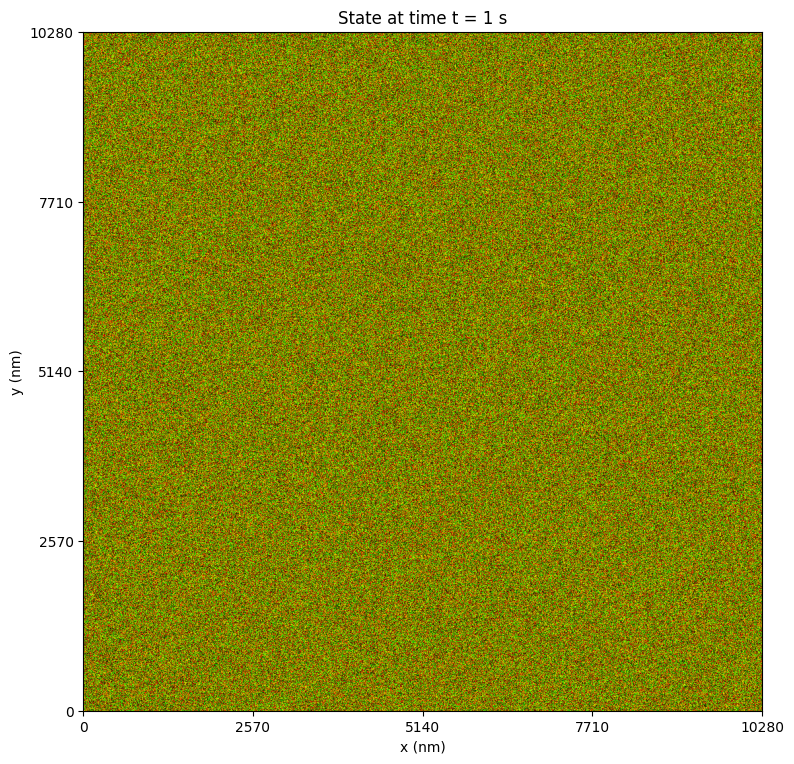

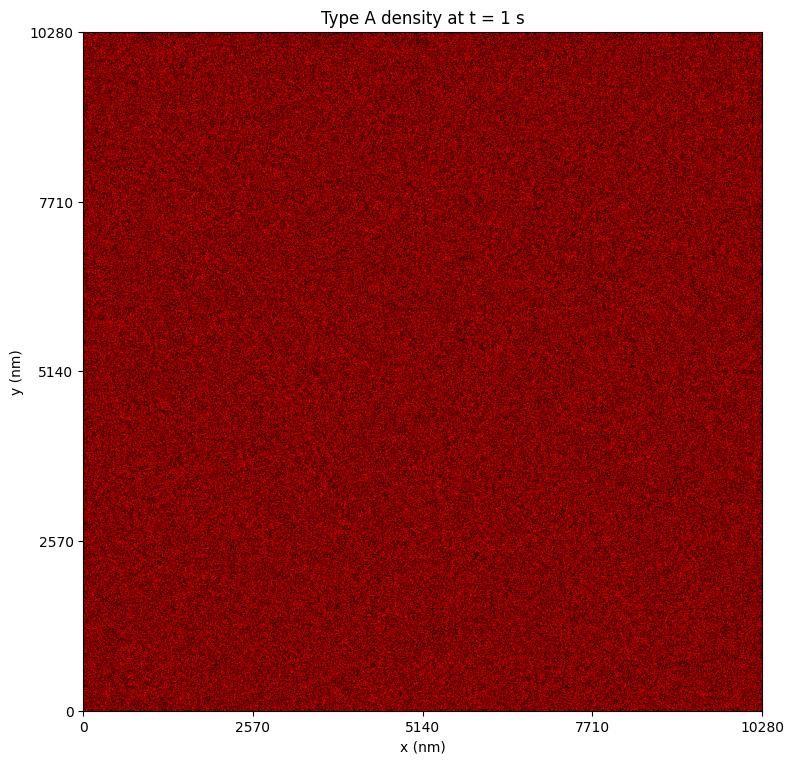

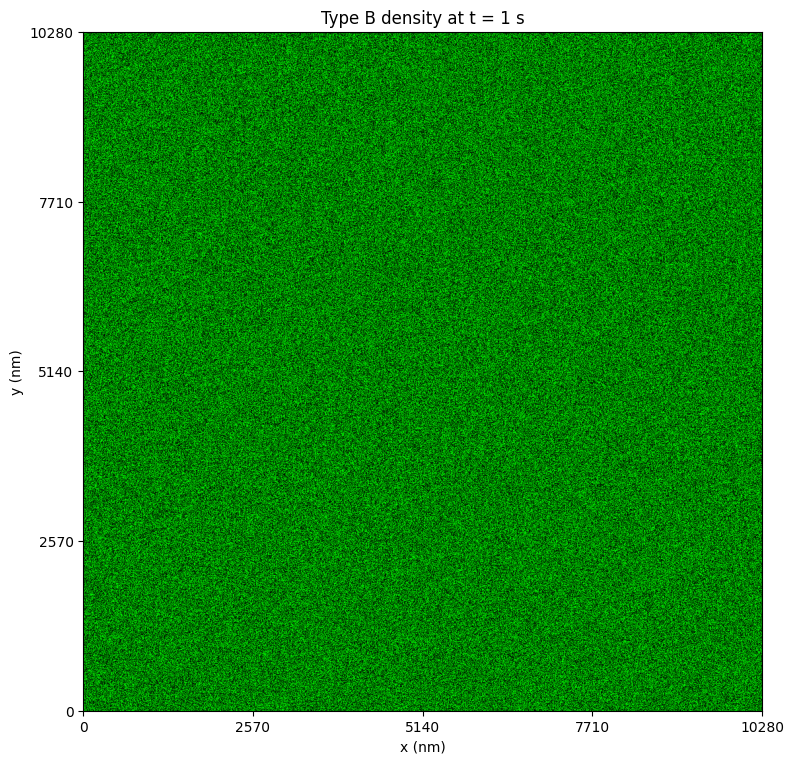

In [ ]:
for step in range(duration):

    # Iterates to find new value of rho
    rho_A_step, rho_B_step = compute_step_two(rho_A, rho_B)
    rho_A += rho_A_step
    rho_B += rho_B_step

    # Adds the new density to the array of densities + checks mass conservation every 10^6 steps
    if step % (save_interval) == 0:
        rho_A_total_array[save_index] = rho_A
        rho_B_total_array[save_index] = rho_B
        save_index += 1

        total_mass = cp.sum(rho_A) + cp.sum(rho_B)

        mass_history.append(total_mass)
        time_history.append(step * dt)

        

        rho_A = cp.maximum(rho_A, floor)        
        rho_B = cp.maximum(rho_B, floor)

        time_elapsed = time.perf_counter() - start_time
        with open(progress_file, "w") as f:
            f.write(f"Progress: {step // save_interval} out of {duration // save_interval} "
                     f"at {time_elapsed:.1f} seconds\n")

        if step % (save_interval * 10) == 0:
            rho_A_np = rho_A.get()
            rho_B_np = rho_B.get()
            
            normalized_A = (rho_A_np - np.min(rho_A_np)) / (np.max(rho_A_np)- np.min(rho_A_np)) #- np.min(rho_A_np))
            normalized_B = (rho_B_np - np.min(rho_B_np)) / (np.max(rho_B_np)- np.min(rho_B_np)) #- np.min(rho_B_np))
            
            rgb_image = np.dstack((normalized_A, normalized_B, np.zeros_like(normalized_B)))
            red_image = np.dstack((normalized_A, np.zeros_like(normalized_A), np.zeros_like(normalized_A)))
            green_image = np.dstack((np.zeros_like(normalized_B), normalized_B, np.zeros_like(normalized_B)))
            t_final = (save_index - 1) * save_interval * dt
            
            tick_positions = [0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length]
            
            
            
            save_image(rgb_image, f"State at time t = {t_final:.0f} s", f"{num_saves-1}_timesteps_rho_total.png")
            save_image(red_image, f"Type A density at t = {t_final:.0f} s", f"{num_saves-1}_timesteps_rho_A.png")
            save_image(green_image, f"Type B density at t = {t_final:.0f} s", f"{num_saves-1}_timesteps_rho_B.png")
        
        
        if step % (save_interval * 25) == 0:
            fig, ax = plt.subplots(figsize=(8, 8))
            n_frames = len(rho_A_total_array)
            
            
            # Compute global min/max across all frames
            A_min  = min(rho_A_total_array[i].get().min()  for i in range(n_frames))
            A_max  = max(rho_A_total_array[i].get().max()  for i in range(n_frames))
            B_min  = min(rho_B_total_array[i].get().min()  for i in range(n_frames))
            B_max  = max(rho_B_total_array[i].get().max()  for i in range(n_frames))
            
            
                
            # Build first frame
            rho_A_i  = rho_A_total_array[0].get()
            rho_B_i  = rho_B_total_array[0].get()
            rgb0 = np.dstack((
                normalize_global(rho_A_i,  A_min,  A_max),
                normalize_global(rho_B_i,  B_min,  B_max),
                np.zeros_like(normalize_global(rho_B_i, B_min, B_max)),
            ))
            
            
            im = ax.imshow(rgb0, extent=[0, grid_length, 0, grid_length], origin='lower', animated=True)
            ax.set_xlabel("x (nm)")
            ax.set_ylabel("y (nm)")
            ax.set_xticks([0, grid_length/4, grid_length/2, 3*grid_length/4, grid_length])
            ax.set_yticks([0, grid_length/4, grid_length/2, 3*grid_length/4, grid_length])
            title = ax.set_title("")
            
                
            ani = animation.FuncAnimation(fig, update, frames=range(n_frames), interval=1, blit=True)
            ani.save(os.path.join(output_dir, f"{num_saves-1}_timesteps_rho_animation.gif"), writer="pillow", dpi=80)

In [ ]:
#Final Save

rho_A_np = rho_A.get()
rho_B_np = rho_B.get()

normalized_A = (rho_A_np - np.min(rho_A_np)) / (np.max(rho_A_np)- np.min(rho_A_np)) #- np.min(rho_A_np))
normalized_B = (rho_B_np - np.min(rho_B_np)) / (np.max(rho_B_np)- np.min(rho_B_np)) #- np.min(rho_B_np))

rgb_image = np.dstack((normalized_A, normalized_B, np.zeros_like(normalized_B)))
red_image = np.dstack((normalized_A, np.zeros_like(normalized_A), np.zeros_like(normalized_A)))
green_image = np.dstack((np.zeros_like(normalized_B), normalized_B, np.zeros_like(normalized_B)))
t_final = (save_index - 1) * save_interval * dt

tick_positions = [0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length]



save_image(rgb_image, f"State at time t = {t_final:.0f} s", f"FINAL_{num_saves-1}_timesteps_rho_total.png")
save_image(red_image, f"Type A density at t = {t_final:.0f} s", f"FINAL_{num_saves-1}_timesteps_rho_A.png")
save_image(green_image, f"Type B density at t = {t_final:.0f} s", f"FINAL_{num_saves-1}_timesteps_rho_B.png")


fig, ax = plt.subplots(figsize=(8, 8))
n_frames = len(rho_A_total_array)


# Compute global min/max across all frames
A_min  = min(rho_A_total_array[i].get().min()  for i in range(n_frames))
A_max  = max(rho_A_total_array[i].get().max()  for i in range(n_frames))
B_min  = min(rho_B_total_array[i].get().min()  for i in range(n_frames))
B_max  = max(rho_B_total_array[i].get().max()  for i in range(n_frames))


    
# Build first frame
rho_A_i  = rho_A_total_array[0].get()
rho_B_i  = rho_B_total_array[0].get()
rgb0 = np.dstack((
    normalize_global(rho_A_i,  A_min,  A_max),
    normalize_global(rho_B_i,  B_min,  B_max),
    np.zeros_like(normalize_global(rho_B_i, B_min, B_max)),
))


im = ax.imshow(rgb0, extent=[0, grid_length, 0, grid_length], origin='lower', animated=True)
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_xticks([0, grid_length/4, grid_length/2, 3*grid_length/4, grid_length])
ax.set_yticks([0, grid_length/4, grid_length/2, 3*grid_length/4, grid_length])
title = ax.set_title("")

    
ani = animation.FuncAnimation(fig, update, frames=range(n_frames), interval=1, blit=True)
ani.save(os.path.join(output_dir, f"{num_saves-1}_timesteps_rho_animation.gif"), writer="pillow", dpi=80)
plt.show()

In [ ]:
rho_A_final = rho_A_total_array[-1]
rho_B_final = rho_B_total_array[-1]

total_points = rho_A_final.shape[0] * rho_A_final.shape[1]

dilute_thresh_A = cp.percentile(rho_A_final, 20)
dense_thresh_A = cp.percentile(rho_A_final, 75)
dilute_thresh_B = cp.percentile(rho_B_final, 20)
dense_thresh_B = cp.percentile(rho_B_final, 75)

frac_dilute_A = cp.sum(rho_A_final < dilute_thresh_A) / total_points
frac_dense_A = cp.sum(rho_A_final > dense_thresh_A) / total_points
frac_interfacial_A = 1.0 - frac_dilute_A - frac_dense_A

frac_dilute_B = cp.sum(rho_B_final < dilute_thresh_B) / total_points
frac_dense_B = cp.sum(rho_B_final > dense_thresh_B) / total_points
frac_interfacial_B = 1.0 - frac_dilute_B - frac_dense_B

final_file = os.path.join(output_dir, f"{num_saves-1}_timesteps_final_checks.txt")

with open(final_file, "a") as f:
    if abs(mass_history[0] - mass_history[-1]) >= 1E-9:
        f.write(f"Mass is NOT conserved!! Change in mass is {mass_history[-1] - mass_history[0]}")
    else:
        f.write(f"Mass is conserved."})

    f.write(f"For A, dense phase density is {np.max(rho_A_np)} and dilute phase density is {np.min(rho_A_np)}")
    f.write(f"For B, dense phase density is {np.max(rho_B_np)} and dilute phase density is {np.min(rho_B_np)}") 
    
    f.write(f"Dense phase fraction for A is {frac_dense_A}, dilute is {frac_dilute_A}")
    f.write(f"Dense phase fraction for B is {frac_dense_B}, dilute is {frac_dilute_B}")